<a href="https://colab.research.google.com/github/srishtiarora42006-hue/Answer/blob/main/Decision_tree_assignment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1: Theoretical Questions

**Q1.** What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

-> A decision tree is a supervised machine learning algorithm used for classification and regression , it works like a flowchart structure , it mimics human decsion thinking .

1. root node - It is the topmost node of the decision tree,it represents the whole dataset and the first decsion is made here.
2. Branch - It represents the outcome of the decison helps in connecting nodes together.
3. Leaf nodes - It represents the final outcome of the tree and no further splitting happens after that.

real - life example - Should X buy a washing machine -
- Budget - 50000
 yes - check brand
 no - Don't buy


**Q2.** Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?

-> Gini impurity measures how a randomly chosen element is incorrectly classified, it is easy and faster way to compute and is commonly used for decision tree. Formula = 1 − Σpᵢ²

Entropy measures the randomness or unceratinity in a node , it slightly more expensive to compute beacsue of logarithms , it also commonly used as splitting critrion. Formula = −Σpᵢ log₂(pᵢ).

Gini impurity is the default criterion because it is easy and simpler to compute and generally gives similar tree- splitting results to entropy , while requiring less computation.

**Q3**What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?

-> Overfitting in decision trees occurs when the tree learns the data too closely , including its noise and small patterns and so it performs well on training data but poorly on new/unseen data.
To detect using accuracy compare training accuaracy and testing accuracy , If training data is equal to testing data then model is generalizing well and there is no strong sign of overfitting.
If training data accuracy is higher than testing data accuracy then there is likely overfitting and if both are low then there is underfitting present.

**Q4.** Explain Pruning in Decision Trees.What is the difference between Pre-pruning and Post-pruning?

-> Prunning means reducing the size of the decision tree by removing unnecessary branches , pruning prevents overfitting and improves model generalization and makes tree simpler and interpretable.

Pre pruning is the process to stop the growth of the decision tree while it is growing or before it becomes too complex and certain conditions are set to limit the size of the decision tree.

post pruning is the process of the first growing the decison tree and then when it grows then removing the unnecessary branches . It simplifies the tree and can improve its ability to generalize to new data.

**Q5**. What is Feature Importance?
How can it help businesses in decision-making?

-> Feautre importance lets the user know how much each feautre contributes to predictions made by a machine learning model . in a decision tree , it shows which variables are most useful for making decsions and splitting data

Feature Importance can help businesses:

- Identify key factors that influence customer decisions.
- Focus on important variables when planning marketing campaigns.
- Improve resource allocation by concentrating efforts on factors that have greater impact.
- Understand customer behaviour and make more data-driven decisions.
- Simplify models by identifying less important features that may not be necessary.

Section 2: Practical Questions (Hands-on using your dataset)

**Q6**. Data Understanding

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

In [73]:
import pandas as pd
df = pd.read_excel("/content/bank.xlsx")

In [74]:
# first 5 rows
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [75]:
#shapE of the dataset
df.shape

(11162, 17)

In [76]:
#data types present in the dataset
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [77]:
#column names
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Interpret:

What types of variables are present?

-> Tjere are numerical and categorical variables present in this datset , numerical ones are - age, balance, day, duration, campaign, pdays, and previous and categorical includes - job, marital, education, default, housing, loan, contact, month, and poutcome.

**Q7.** Data Cleaning

Check for missing values

Handle missing values (if any)

Check for duplicates

In [78]:
# detecting missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [79]:
#as there are no missing values , hence no imputation is needed

In [80]:
#checking for duplicates
df.duplicated().any()
# no duplicates detected

np.False_

Interpret:

Is the dataset clean? What issues did you find?

-> Yes the dataset is quite clean as there are no missing values and duplicates present in this data.

**Q8.** Data Preprocessing

Convert categorical variables into numerical

Mention which encoding method you used

In [81]:
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'], drop_first= True)

In [82]:
df["deposit"]=df["deposit"].map({"yes":1,"no":0})

Encoding method used - One hot encoding

Interpret:

Why is encoding necessary for Decision Trees?

->Encoding is necessary because machine learning models generally require input data in numerical form. Our Bank Marketing dataset contains categorical variables such as job, education, marital, and contact, which contain text values.

Encoding converts these categories into numerical values so that the Decision Tree can process them and use them for making splits

**Q9.** Feature Selection & Splitting

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

In [83]:
# seperating X nd y
X = df.drop(columns=["deposit"])
y = df["deposit"]

In [84]:
#performing train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Interpret:

Why is train-test split important?

-> Train test split is important as it converts the datset into 2 sections i.e training data - 80% of the data and testing data i.e 20% of the data which helps in model training , It helps us determine whether the model has learned useful patterns rather than simply memorizing the training data. It also helps in detecting problems such as overfitting.

**Q10.** Model Building

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5


In [85]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state= 42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Interpret:

What does max_depth control?

-> max_depth controls the maximum depth (number of levels) of a Decision Tree.

Higher max_depth → deeper, more complex tree → can learn more detailed patterns but may overfit.
Lower max_depth → smaller, simpler tree → reduces complexity and can help prevent overfitting.

**Q11.** Model Evaluation

Perform:

Accuracy score

Confusion Matrix

Classification Report

In [86]:
#predictions
y_pred = model.predict(X_test)

# Accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7948947604120018


In [87]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion)

Confusion Matrix:
[[925 241]
 [217 850]]


In [88]:
# Classification score
from sklearn.metrics import classification_report
classification = classification_report(y_test, y_pred)
print("Classification Report:")
print(classification)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



Interpret (MUST):

Is the model performing well?

Explain Precision & Recall

Any class imbalance issue?

-> 1. The model is showing 79% accuracy meaning it correctly predicts 79% of the testing observations , the precision , recall , and F1 scores are also around 0.79-0.81 , showing fairly consistent performance.

2. Class0 : precision =0.81, recall = 0.79
- Precision 0.81 means that 81% of the observations predicted as class 0 were actually class 0 .
- recall 0.79 means that the model correctly identified 79% of the actual class 0 predictions .

Class 1: Precision = 0.78, Recall = 0.80

- Precision 0.78 means that 78% of the observations predicted as Class 1 were actually Class 1.
- Recall 0.80 means that the model correctly identified 80% of the actual Class 1 observations.

3. no such imbalance issue classes are fairly balanced .

**Q12.** Overfitting Check

Calculate:

Training accuracy

Testing accuracy

->

In [89]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8106170903796618
Testing Accuracy: 0.7948947604120018


Interpret:

Is the model overfitting or underfitting?

-> The model is not significantly overfitting or underfitting , the training accuracy i.e 81.06% and testing accuracy i.e 79.49% are quite close with only a slight diffrence of around 1.57% , this shows that the model is generalizing well to unseen data.

**Q13.** Pruning Experiment

Train another model with:

max_depth=3

min_samples_split=20



In [90]:
pruned_model = DecisionTreeClassifier(criterion ="gini",max_depth=3, min_samples_split=20, random_state=42)
pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)

In [91]:
print("Training Accuracy:", pruned_model.score(X_train, y_train))
print("Testing Accuracy:", pruned_model.score(X_test, y_test))

Training Accuracy: 0.7816104826968305
Testing Accuracy: 0.7693685624720108


Interpret:

Compare performance with previous model

Which one is better and why?

->The unpruned model has higher training and testing accuracy than the pruned model. However, the pruned model has a slightly smaller gap between training and testing accuracy, indicating slightly less overfitting. Based on accuracy, the unpruned model performs better on the test data.

**Q14.** Feature Importance

Extract top 5 important features

Plot feature importance graph

In [92]:
importance = pd.Series(model.feature_importances_,index=X.columns)
top5 = importance.sort_values(ascending = False).head(5)
print(top5)


duration            0.605731
poutcome_success    0.156779
contact_unknown     0.143572
housing_yes         0.036242
month_mar           0.032596
dtype: float64


Text(0, 0.5, 'Features')

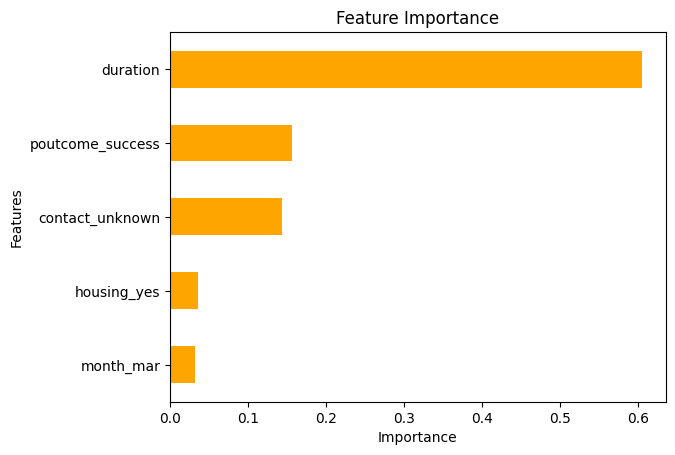

In [93]:
#plotting feautre importance graph
import matplotlib.pyplot as plt

top5.sort_values().plot(kind = "barh", color = "orange")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

Interpret:

Which features influence prediction the most?

-> Duration is the most influential factor for predictions.

**Q15.** Business Insights

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank use?

->

In [96]:
pd.crosstab(df["poutcome_success"], df["deposit"], normalize="index") * 100

deposit,0,1
poutcome_success,,
False,57.278763,42.721237
True,8.683473,91.316527


 ->  This shows that people who had a successfull previous campaign are more likely to say "yes" to deposits as it shows 91.31% said yes.

 -> The bank should use previous campaign outcomes to identify high-potential customers and prioritize customers with successful past interactions for targeted marketing campaigns. This can help the bank focus its efforts on customers who have shown a positive response in the past.

